GitHub: https://github.com/TrungVN9/final_project

## What is Quantum Computing?

Imagine you have a toy box with balls. In regular computers, each ball is either red or blue, and you can only pick one color at a time. But in quantum computers, the balls can be both red AND blue at the same time! That's called superposition. It's like magic!

A qubit is like one of these special balls. Instead of just 0 or 1 like regular bits, a qubit can be 0, 1, or both at once. Cool, right?

In this program, we'll play with one qubit and see what happens when we measure it.

In [54]:
from qiskit import QuantumCircuit, transpile
from qiskit_aer import AerSimulator

### Tools Use
Just like you need crayons and paper to draw, we need special tools for quantum computing. Qiskit is like a big box of quantum toys!

- `QuantumCircuit`: This is our drawing paper where we build the quantum circuit.
- `transpile`: This is like translating our drawing so the computer can understand it.
- `AerSimulator`: This is a pretend quantum computer on your regular computer. It's like playing with toy cars instead of real ones.

In [55]:
# Create a quantum circuit with 1 qubit and 1 classical bit
qc = QuantumCircuit(1, 1)

# Apply Hadamard gate
qc.h(0)

# Measure
qc.measure(0, 0)

## Building Quantum Circuit

1. **QuantumCircuit(1, 1)**: We make a circuit with 1 qubit (the special ball) and 1 classical bit (to write down what we see).

2. **qc.h(0)**: The Hadamard gate! It's like shaking the ball really hard. Before, the qubit was just 0. After shaking, it's both 0 AND 1 at the same time! That's superposition. The H stands for Hadamard, a smart scientist who invented this trick.

3. **qc.measure(0, 0)**: We look at the qubit and write down what we see. When we measure, the magic stops and it becomes just 0 or 1. It's like opening your eyes to see if the ball is red or blue.

Now Draw Circuit to see what it looks like

In [56]:
# Let's see what our circuit looks like!
qc.draw(output='text')

┌───┐┌─┐
  q: ┤ H ├┤M├
     └───┘└╥┘
c: 1/══════╩═
           0

In [57]:
# Use AerSimulator
simulator = AerSimulator()

# Transpile the circuit
compiled_circuit = transpile(qc, simulator)

# Run the circuit
job = simulator.run(compiled_circuit, shots=1000)
result = job.result()

# Get counts
counts = result.get_counts()
print(counts)

{'0': 467, '1': 533}


## Running Circuit

We run our circuit 1000 times (that's called "shots"). Each time, we shake the qubit with the H gate and then look at it.

Before measuring, it's both 0 and 1. When we measure, it randomly picks one!

You should see something like `{'0': 500, '1': 500}`. That means about half the time we got 0, half the time 1. That's because the H gate makes it fair - 50/50 chance!

If it was always 0 or always 1, that wouldn't be quantum computing!

## The Bell State!

We'll use 2 qubits and make them "entangled." That's when two qubits are connected -  what happens to one affects the other, even far apart!

This is called a Bell state

In [58]:
# Create a Bell state circuit with 2 qubits
bell_qc = QuantumCircuit(2, 2)

# Put first qubit in superposition
bell_qc.h(0)

# Entangle them with CNOT gate
bell_qc.cx(0, 1)

# Measure both
bell_qc.measure_all()

print("Bell State Circuit:")
print(bell_qc.draw(output='text'))

Bell State Circuit:
        ┌───┐      ░ ┌─┐   
   q_0: ┤ H ├──■───░─┤M├───
        └───┘┌─┴─┐ ░ └╥┘┌─┐
   q_1: ─────┤ X ├─░──╫─┤M├
             └───┘ ░  ║ └╥┘
   c: 2/══════════════╬══╬═
                      ║  ║ 
meas: 2/══════════════╩══╩═
                      0  1 


### What's Happening in the Bell State?

1. **bell_qc.h(0)**: Shake the first qubit so it's both 0 and 1.

2. **bell_qc.cx(0, 1)**: This is a CNOT gate! It's like saying "If the first qubit is 1, flip the second qubit." Now they're connected!

3. **bell_qc.measure_all()**: Look at both qubits at the same time.

When running this, the result always get either '00' or '11' - never '01' or '10'! That's entanglement. The qubits agree on what to be, even though each is random.

In [59]:
# Run the Bell state circuit
bell_compiled = transpile(bell_qc, simulator)
bell_job = simulator.run(bell_compiled, shots=1000)
bell_result = bell_job.result()
bell_counts = bell_result.get_counts()
print("Bell State Results:")
print(bell_counts)

Bell State Results:
{'00 00': 510, '11 00': 490}


## Use Case 1: Quantum Interference

Quantum computers can do something special called interference. It's like waves in water that can add together or cancel each other out.

In quantum world, gates are like wave moves. When we use the Hadamard gate twice in a row, the second one cancels the first one. That means the qubit comes back to 0 every time. This is a simple way to see how quantum computers can use wave patterns to solve problems.

In [60]:
# Quantum interference example: H then H returns the qubit to 0
interference_qc = QuantumCircuit(1, 1)
interference_qc.h(0)
interference_qc.h(0)
interference_qc.measure(0, 0)

print("Interference Circuit:")
print(interference_qc.draw(output='text'))

interference_compiled = transpile(interference_qc, simulator)
interference_result = simulator.run(interference_compiled, shots=1000).result()
interference_counts = interference_result.get_counts()
print("Interference counts:")
print(interference_counts)

Interference Circuit:
     ┌───┐┌───┐┌─┐
  q: ┤ H ├┤ H ├┤M├
     └───┘└───┘└╥┘
c: 1/═══════════╩═
                0 
Interference counts:
{'0': 1000}


## Use Case 2: Quantum Search with Grover's Idea

Quantum computers can search large spaces faster by using interference in a clever way. This tiny example shows the idea: we make the answer `11` more likely.

We use a special oracle that marks `11`, then a diffuser that makes the right answer shine brighter. Even though this is a small example, it shows the key idea behind quantum search.

In [61]:
# Simple 2-qubit Grover-like search for the answer '11'
grover_qc = QuantumCircuit(2, 2)

grover_qc.h([0, 1])  # Create superposition for both qubits

# Oracle for target '11': flip the phase only when both qubits are 1
grover_qc.cz(0, 1)

# Diffuser to amplify the marked result
grover_qc.h([0, 1])
grover_qc.x([0, 1])
grover_qc.h(1)
grover_qc.cx(0, 1)
grover_qc.h(1)
grover_qc.x([0, 1])
grover_qc.h([0, 1])

grover_qc.measure([0, 1], [0, 1])

print("Grover-like Search Circuit:")
print(grover_qc.draw(output='text'))

grover_compiled = transpile(grover_qc, simulator)
grover_result = simulator.run(grover_compiled, shots=1000).result()
grover_counts = grover_result.get_counts()
print("Grover search counts:")
print(grover_counts)

Grover-like Search Circuit:
     ┌───┐   ┌───┐┌───┐          ┌───┐┌───┐     ┌─┐   
q_0: ┤ H ├─■─┤ H ├┤ X ├───────■──┤ X ├┤ H ├─────┤M├───
     ├───┤ │ ├───┤├───┤┌───┐┌─┴─┐├───┤├───┤┌───┐└╥┘┌─┐
q_1: ┤ H ├─■─┤ H ├┤ X ├┤ H ├┤ X ├┤ H ├┤ X ├┤ H ├─╫─┤M├
     └───┘   └───┘└───┘└───┘└───┘└───┘└───┘└───┘ ║ └╥┘
c: 2/════════════════════════════════════════════╩══╩═
                                                 0  1 
Grover search counts:
{'11': 1000}


## Why This Matters

- **Interference** shows how quantum computers can make good answers stronger and bad answers cancel out.
- **Entanglement** shows how quantum bits can work together in a way no regular computer can.
- **Quantum search** shows the idea of finding a special answer faster by using waves and phase tricks.

These ideas are why quantum computers are exciting for future problems like searching huge data sets, breaking hard puzzles, and creating new materials.

## Use Case 3: Quantum Optimization (QAOA)

This use case demonstrates a quantum optimization algorithm called QAOA. This example solves a simple Max-Cut problem for two connected nodes.

Imagine two friends who want to sit in different groups. The best answer is when one is on one side and the other is on the opposite side. Quantum optimization helps find that good answer by using quantum states and angles.

In [62]:
import numpy as np

# Max-cut cost for 2 nodes: reward 1 when bits differ

def maxcut_cost(bitstring):
    return 1 if bitstring[0] != bitstring[1] else 0

# Build a single-layer QAOA circuit for a 2-node Max-Cut problem
def qaoa_circuit(gamma, beta):
    qaoa = QuantumCircuit(2, 2)
    qaoa.h([0, 1])
    qaoa.cx(0, 1)
    qaoa.rz(2 * gamma, 1)
    qaoa.cx(0, 1)
    qaoa.rx(2 * beta, [0, 1])
    qaoa.measure([0, 1], [0, 1])
    return qaoa

# Evaluate the circuit for a grid of angles
best = {"cost": -1}
for gamma in np.linspace(0, np.pi, 5):
    for beta in np.linspace(0, np.pi / 2, 5):
        circ = qaoa_circuit(gamma, beta)
        compiled = transpile(circ, simulator)
        result = simulator.run(compiled, shots=1000).result()
        counts = result.get_counts()
        expected = sum(maxcut_cost(bit) * count for bit, count in counts.items()) / 1000
        if expected > best["cost"]:
            best = {
                "gamma": float(gamma),
                "beta": float(beta),
                "cost": float(expected),
                "counts": counts,
            }

print("Best QAOA expected Max-Cut value:", best["cost"])
print("Best angles: gamma=", best["gamma"], "beta=", best["beta"])
print("Counts for best setting:")
print(best["counts"])

Best QAOA expected Max-Cut value: 1.0
Best angles: gamma= 0.7853981633974483 beta= 1.1780972450961724
Counts for best setting:
{'10': 491, '01': 509}


## Visualization QAOA vs Random Guess

Comparison between the optimized quantum result with a random guess. The quantum algorithm should make the best answers more likely, shwoing in a bar chart as indicated to show how often each possible solution appears.

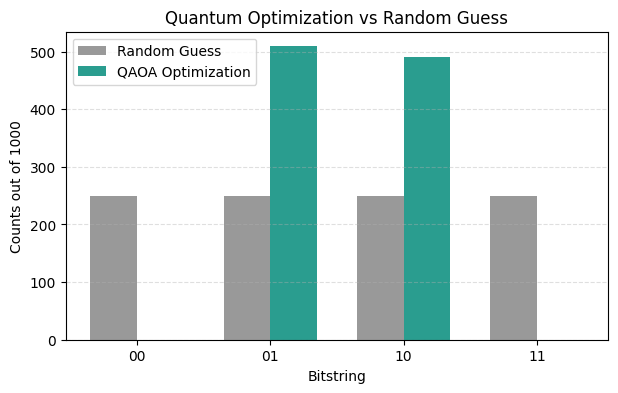

In [63]:
import matplotlib.pyplot as plt

# Build random counts for comparison
random_counts = {"00": 250, "01": 250, "10": 250, "11": 250}

def plot_counts(qaoa_counts, random_counts):
    labels = ["00", "01", "10", "11"]
    qaoa_values = [qaoa_counts.get(label, 0) for label in labels]
    random_values = [random_counts.get(label, 0) for label in labels]

    x = np.arange(len(labels))
    width = 0.35

    fig, ax = plt.subplots(figsize=(7, 4))
    ax.bar(x - width / 2, random_values, width, label='Random Guess', color='#999999')
    ax.bar(x + width / 2, qaoa_values, width, label='QAOA Optimization', color='#2a9d8f')

    ax.set_xlabel('Bitstring')
    ax.set_ylabel('Counts out of 1000')
    ax.set_title('Quantum Optimization vs Random Guess')
    ax.set_xticks(x)
    ax.set_xticklabels(labels)
    ax.legend()
    ax.grid(axis='y', linestyle='--', alpha=0.4)
    plt.show()

plot_counts(best['counts'], random_counts)

# Classical vs Quantum Database Search Comparison

Checking index 0000 -> Alice
Checking index 0001 -> Bob
Checking index 0010 -> Charlie
Checking index 0011 -> David
Checking index 0100 -> Emma
Checking index 0101 -> Frank
Checking index 0110 -> Grace

CLASSICAL SEARCH RESULT
Database Size: 16
Target Name: Grace
Found Index: 0110
Operations Required: 7

QUANTUM SEARCH RESULT
Dataset Size: 16
Target State: 0110
Most Likely State: 0110
Database Record: Grace
Grover Success Rate: 0.9521484375
Estimated Grover Iterations: 3


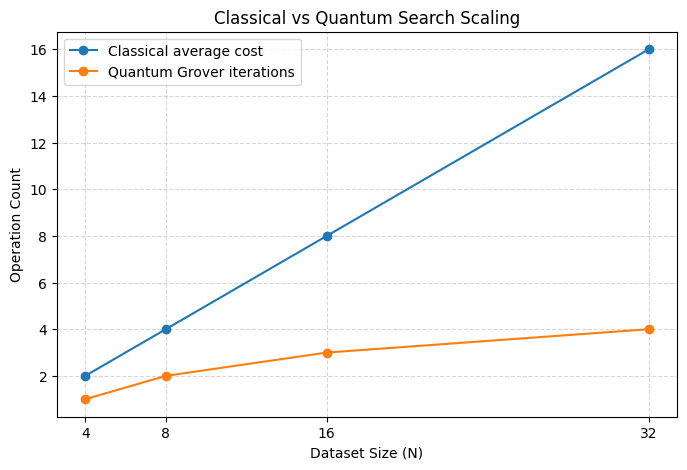

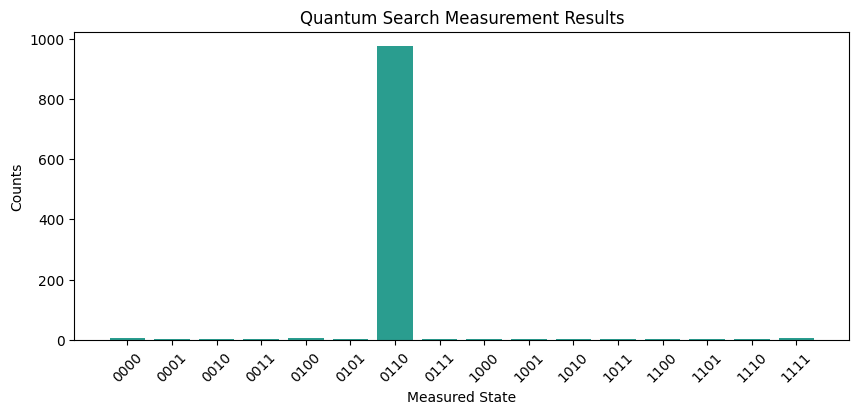


Data used for comparison:
N=4: classical ~2.0, quantum ~1
N=8: classical ~4.0, quantum ~2
N=16: classical ~8.0, quantum ~3
N=32: classical ~16.0, quantum ~4


In [64]:
# ==========================================================
# CLASSICAL DATABASE SEARCH
# ==========================================================

# Larger dataset of 16 entries for a stronger comparison
names = [
    "Alice", "Bob", "Charlie", "David",
    "Emma", "Frank", "Grace", "Henry",
    "Irene", "Jack", "Karen", "Leo",
    "Mia", "Nate", "Olivia", "Paul"
]

database = {format(i, '04b'): names[i] for i in range(len(names))}

target_name = "Grace"

# ----------------------------------------------------------
# Classical Linear Search
# ----------------------------------------------------------

operations = 0
found_key = None

for key, value in database.items():
    operations += 1
    print(f"Checking index {key} -> {value}")
    if value == target_name:
        found_key = key
        break

print("\nCLASSICAL SEARCH RESULT")
print("Database Size:", len(database))
print("Target Name:", target_name)
print("Found Index:", found_key)
print("Operations Required:", operations)

# Compute average classical cost for comparison
average_classical_cost = sum(i + 1 for i in range(len(database))) / len(database)

# ==========================================================
# QUANTUM DATABASE SEARCH USING GROVER'S ALGORITHM
# ==========================================================

from qiskit import QuantumCircuit, transpile
from qiskit_aer import AerSimulator
import numpy as np
import matplotlib.pyplot as plt

# Choose the target state based on the database lookup
target_state = [key for key, value in database.items() if value == target_name][0]

n_qubits = 4
N = 2**n_qubits

qc = QuantumCircuit(n_qubits, n_qubits)

# ----------------------------------------------------------
# STEP 1: SUPERPOSITION
# ----------------------------------------------------------

qc.h(range(n_qubits))

# ----------------------------------------------------------
# ORACLE
# ----------------------------------------------------------

def oracle(qc, target_state):
    for idx, bit in enumerate(target_state):
        if bit == '0':
            qc.x(idx)

    qc.h(n_qubits - 1)
    qc.mcx(list(range(n_qubits - 1)), n_qubits - 1)
    qc.h(n_qubits - 1)

    for idx, bit in enumerate(target_state):
        if bit == '0':
            qc.x(idx)

# ----------------------------------------------------------
# DIFFUSER
# ----------------------------------------------------------

def diffuser(qc):
    qc.h(range(n_qubits))
    qc.x(range(n_qubits))
    qc.h(n_qubits - 1)
    qc.mcx(list(range(n_qubits - 1)), n_qubits - 1)
    qc.h(n_qubits - 1)
    qc.x(range(n_qubits))
    qc.h(range(n_qubits))

# ----------------------------------------------------------
# GROVER ITERATIONS
# ----------------------------------------------------------

iterations = int(np.floor((np.pi / 4) * np.sqrt(N)))

for _ in range(iterations):
    oracle(qc, target_state)
    diffuser(qc)

# ----------------------------------------------------------
# MEASURE
# ----------------------------------------------------------

qc.measure(range(n_qubits), range(n_qubits))

# ----------------------------------------------------------
# RUN
# ----------------------------------------------------------

simulator = AerSimulator()
compiled = transpile(qc, simulator)
job = simulator.run(compiled, shots=1024)
result = job.result()
counts = result.get_counts()

most_likely_state = max(counts, key=counts.get)
quantum_success_rate = counts.get(target_state, 0) / 1024

print("\nQUANTUM SEARCH RESULT")
print("Dataset Size:", N)
print("Target State:", target_state)
print("Most Likely State:", most_likely_state)
print("Database Record:", database[most_likely_state])
print("Grover Success Rate:", quantum_success_rate)
print("Estimated Grover Iterations:", iterations)

# ----------------------------------------------------------
# COLLECT DATA FOR PLOT
# ----------------------------------------------------------

dataset_sizes = [4, 8, 16, 32]
classical_costs = [size / 2 for size in dataset_sizes]
quantum_costs = [np.floor((np.pi / 4) * np.sqrt(size)) for size in dataset_sizes]

plt.figure(figsize=(8, 5))
plt.plot(dataset_sizes, classical_costs, marker='o', label='Classical average cost')
plt.plot(dataset_sizes, quantum_costs, marker='o', label='Quantum Grover iterations')
plt.xlabel('Dataset Size (N)')
plt.ylabel('Operation Count')
plt.title('Classical vs Quantum Search Scaling')
plt.xticks(dataset_sizes)
plt.grid(True, linestyle='--', alpha=0.5)
plt.legend()
plt.show()

labels = sorted(counts.keys())
values = [counts[label] for label in labels]

plt.figure(figsize=(10, 4))
plt.bar(labels, values, color='#2a9d8f')
plt.xlabel('Measured State')
plt.ylabel('Counts')
plt.title('Quantum Search Measurement Results')
plt.xticks(rotation=45)
plt.show()

print("\nData used for comparison:")
for size, c_cost, q_cost in zip(dataset_sizes, classical_costs, quantum_costs):
    print(f"N={size}: classical ~{c_cost:.1f}, quantum ~{int(q_cost)}")
